# Hiperparametry estymatorow

## LS

In [147]:
import pandas as pd
df_ls = pd.read_csv("../tables/LS_test_results.csv")
df_ls.drop_duplicates(inplace=True)
df_ls.sort_values(by=['wspolczynnik odleglosci', "szerokosc okna"], inplace=True)
df_ls.to_csv("../tables/LS_test_results.csv", index=False)

In [148]:
best_ls = df_ls[df_ls["blad"] == df_ls["blad"].min()]
best_ls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad
539,LS,-,-,9.0,3,539.16


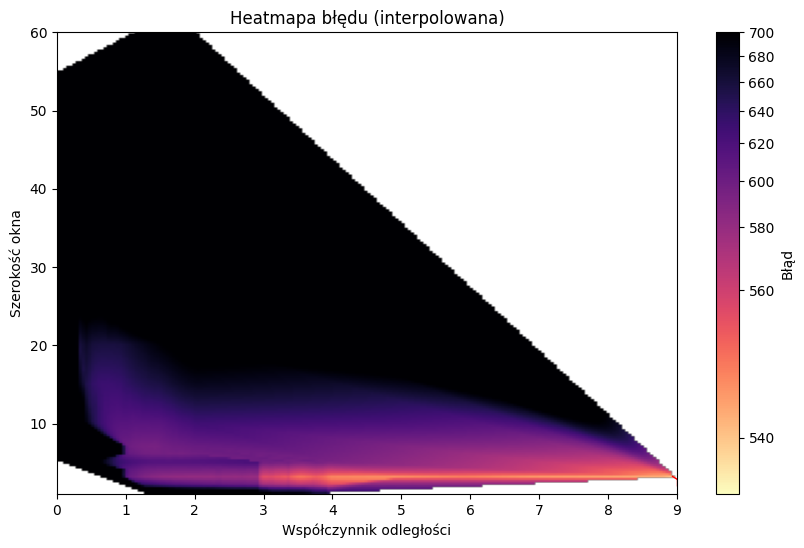

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.interpolate import griddata

x = df_ls["wspolczynnik odleglosci"].values
y = df_ls["szerokosc okna"].values
z = df_ls["blad"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')
norm = colors.PowerNorm(gamma=0.4, vmin=z.min(), vmax=700)
plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto', norm=norm)
cbar = plt.colorbar()
cbar.set_label("Błąd")
plt.scatter(best_ls['wspolczynnik odleglosci'], best_ls['szerokosc okna'],marker="1",s=100, c="red",  linewidth=1)

plt.xlabel("Współczynnik odległości")
plt.ylabel("Szerokość okna")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

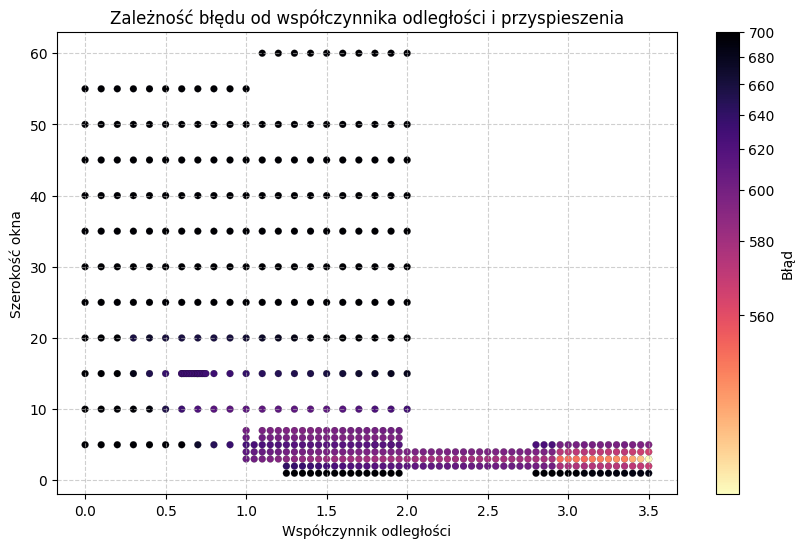

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_ls["wspolczynnik odleglosci"], 
                 df_ls['szerokosc okna'], 
                 c=df_ls['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 norm=norm,
                 linewidth=0.1)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd') 

plt.ylabel("Szerokość okna")
plt.xlabel("Współczynnik odległości")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## DLS

In [164]:
import pandas as pd
df_dls = pd.read_csv("../tables/DLS_test_results.csv")
df_dls.drop_duplicates(inplace=True)
df_dls.sort_values(by=['wspolczynnik odleglosci', 'predkosc','szerokosc okna'], inplace=True)
df_dls.to_csv("../tables/DLS_test_results.csv", index=False)

In [165]:
best_dls = df_dls[df_dls["blad"] == df_dls["blad"].min()]
best_dls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad
1217,DLS,-,1.0,1.4,3,545.9
1219,DLS,-,1.0,1.4,3,545.9


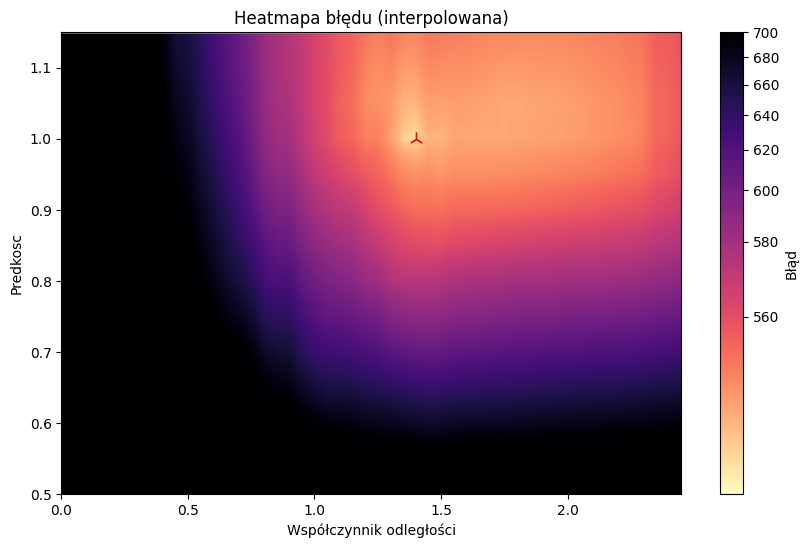

In [167]:
df_dls = df_dls[df_dls["szerokosc okna"]==3]
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

x = df_dls["wspolczynnik odleglosci"].values
y = df_dls['predkosc'].values
z = df_dls["blad"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')
norm = colors.PowerNorm(gamma=0.4, vmin=z.min(), vmax=700)
plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto', norm=norm)
cbar = plt.colorbar()
plt.scatter(best_dls['wspolczynnik odleglosci'], best_dls['predkosc'],marker="2",s=100, c="red", linewidth=1)
cbar.set_label("Błąd")

plt.xlabel("Współczynnik odległości")
plt.ylabel("Predkosc")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

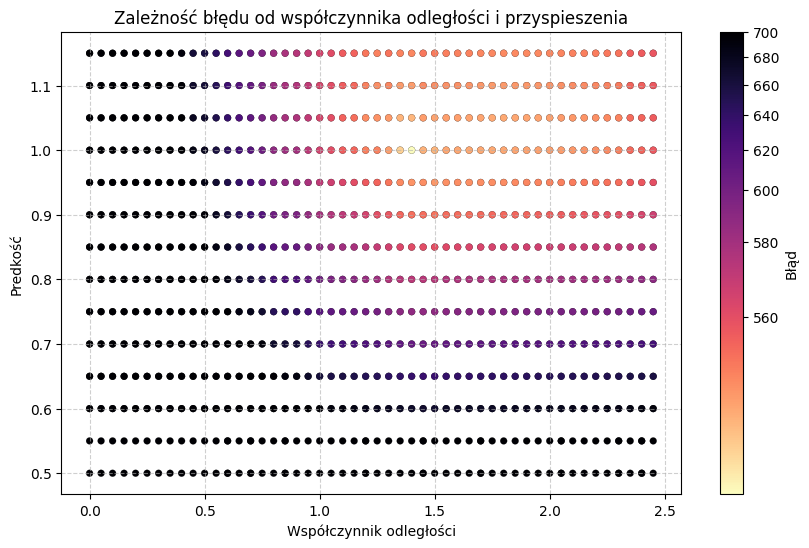

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_dls["wspolczynnik odleglosci"], 
                 df_dls['predkosc'], 
                 c=df_dls['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd') 

plt.ylabel("Predkość")
plt.xlabel("Współczynnik odległości")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## D2LS

In [169]:
import pandas as pd
df_d2ls = pd.read_csv("../tables/D2LS_test_results.csv")
df_d2ls.drop_duplicates(inplace=True)
df_d2ls.sort_values(by=['wspolczynnik odleglosci', 'predkosc', 'przyspieszenie','szerokosc okna'], inplace=True)
df_d2ls.sort_values(by=['Estymator'],ascending=False)
df_d2ls.to_csv("../tables/D2LS_test_results.csv", index=False)

In [171]:
df_d2ls= df_d2ls[df_d2ls["Estymator"]=="D2LS"]
best_d2ls = df_d2ls[df_d2ls["blad"] == df_d2ls["blad"].min()]
best_d2ls

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,szerokosc okna,blad
2120,D2LS,1.05,-,2.4,3,596.51


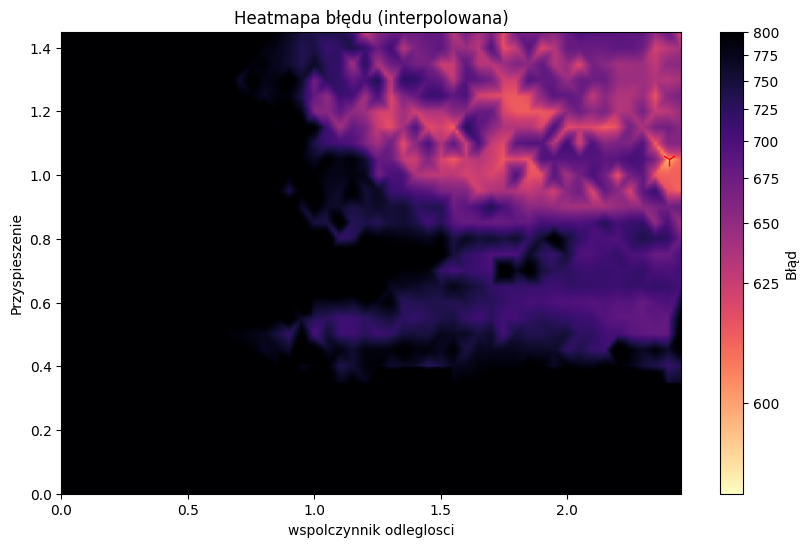

In [172]:
df_d2ls = df_d2ls[df_d2ls['szerokosc okna']==3]
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

x = df_d2ls['wspolczynnik odleglosci'].values
y = df_d2ls['przyspieszenie'].values
z = df_d2ls["blad"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)
norm = colors.PowerNorm(gamma=0.4, vmin=z.min(), vmax=800)
# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='magma_r', aspect='auto',norm=norm)
cbar = plt.colorbar()
plt.scatter(best_d2ls['wspolczynnik odleglosci'], best_d2ls['przyspieszenie'], marker="1",s=100, c="red", linewidth=1)
cbar.set_label("Błąd")

plt.xlabel("wspolczynnik odleglosci")
plt.ylabel("Przyspieszenie")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

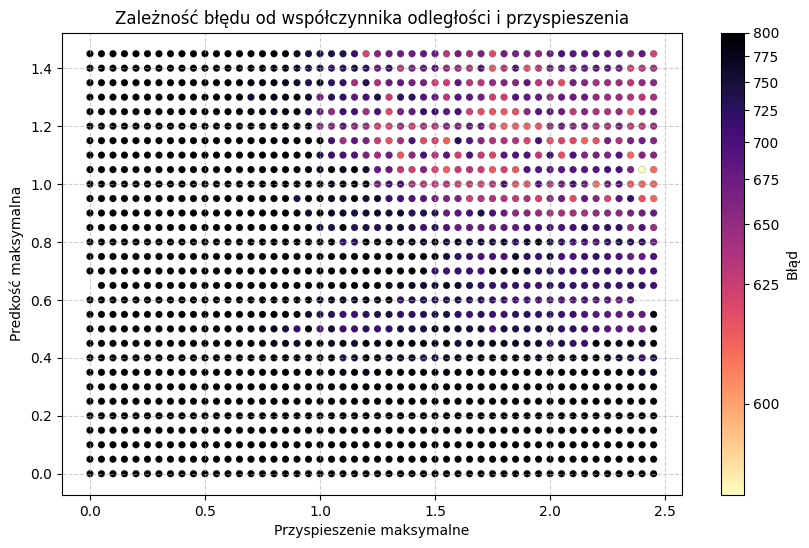

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sc = plt.scatter(df_d2ls['wspolczynnik odleglosci'], 
                 df_d2ls['przyspieszenie'],
                 c=df_d2ls['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd') 

plt.ylabel("Predkość maksymalna")
plt.xlabel("Przyspieszenie maksymalne")
plt.title("Zależność błędu od współczynnika odległości i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## DAMPING

In [183]:
import pandas as pd

df_d2lsd = pd.read_csv("../tables/D2LSD_test_results.csv")
df_d2lsd.sort_values(by=['wspolczynnik odleglosci', 'predkosc', 'przyspieszenie', 'wzmocnienie','szerokosc okna'], inplace=True)
df_d2lsd.drop_duplicates(inplace=True)
df_d2lsd.to_csv("../tables/D2LSD_test_results.csv", index=False)

In [184]:
df_d2lsd =df_d2lsd[df_d2lsd['Estymator']=="D2LSD"]
df_d2lsd =df_d2lsd[df_d2lsd['szerokosc okna']==3]
best_damp = df_d2lsd[df_d2lsd["blad"] == df_d2lsd["blad"].min()]
best_damp

,Estymator,przyspieszenie,predkosc,wspolczynnik odleglosci,wzmocnienie,szerokosc okna,blad
2129,D2LSD,1.0,-,1.4,0.6,3,557.85


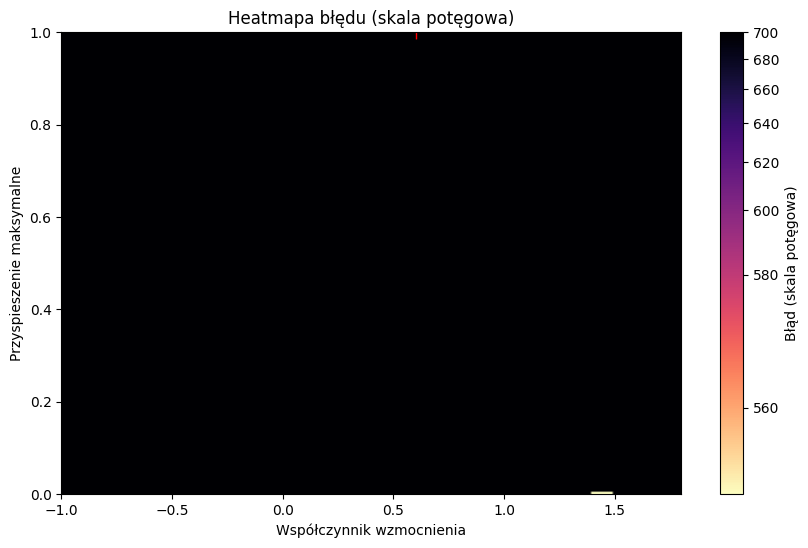

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors 
from scipy.interpolate import griddata

x = df_d2lsd['wzmocnienie'].values
y = df_d2lsd['przyspieszenie'].values
z = df_d2lsd["blad"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')


plt.figure(figsize=(10, 6))

# Kluczowa zmiana: dodajemy parametr norm
norm = colors.PowerNorm(gamma=0.4, vmin=z.min(), vmax=700)
plt.imshow(Zi, 
           extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', 
           cmap='magma_r', 
           aspect='auto',
           norm=norm)

cbar = plt.colorbar()
cbar.set_label("Błąd (skala potęgowa)")

# Reszta wykresu
plt.scatter(best_damp['wzmocnienie'], best_damp['przyspieszenie'], 
            marker="1", s=100, c="red", linewidth=1)

plt.xlabel("Współczynnik wzmocnienia")
plt.ylabel("Przyspieszenie maksymalne")
plt.title("Heatmapa błędu (skala potęgowa)")
plt.show()




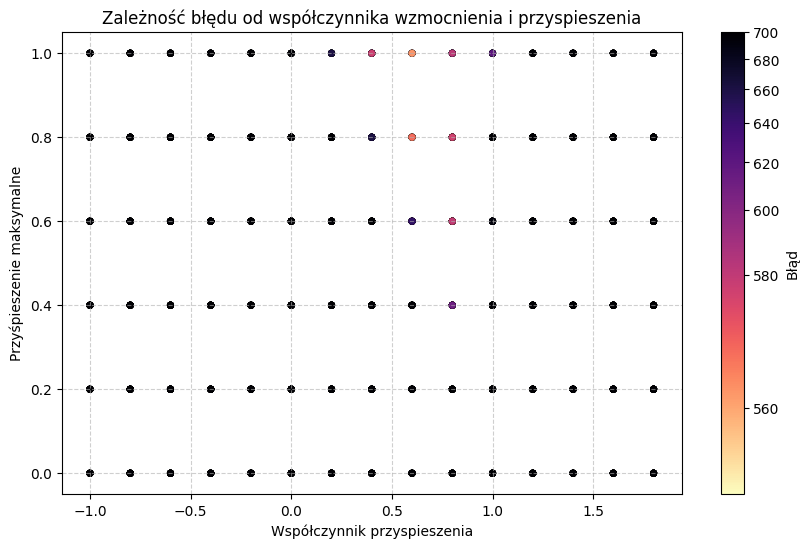

In [186]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_d2lsd['wzmocnienie'], 
                 df_d2lsd['przyspieszenie'],
                 c=df_d2lsd['blad'].astype(float), 
                 cmap='magma_r', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1,
                 norm=norm)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd') 

plt.xlabel("Współczynnik przyspieszenia")
plt.ylabel("Przyśpieszenie maksymalne")
plt.title("Zależność błędu od współczynnika wzmocnienia i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Przybliżenie do najlepszych parametrów

In [116]:
df_d2lsd_2 = df_d2lsd[df_d2lsd["wzmocnienie"] < 1]
df_d2lsd_2 = df_d2lsd_2[df_d2lsd_2["przyspieszenie"] > 0.5]

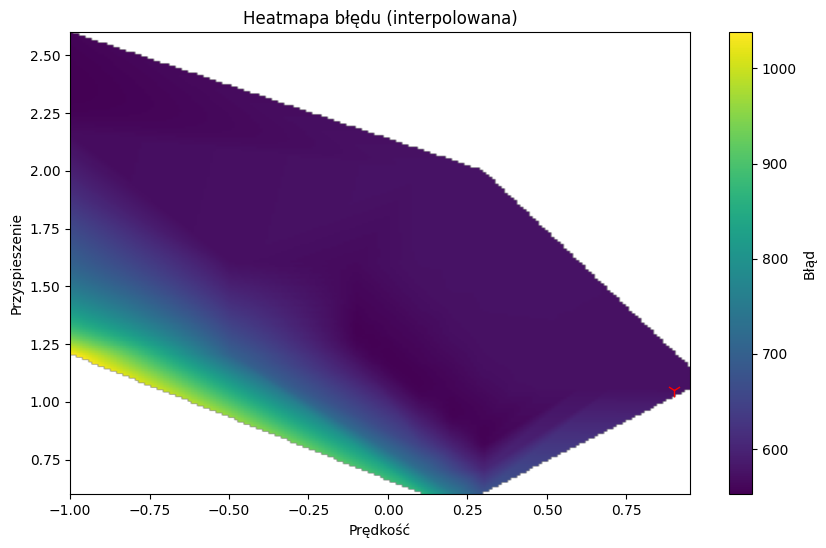

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

x = df_d2lsd_2['wzmocnienie'].values
y = df_d2lsd_2['przyspieszenie'].values
z = df_d2lsd_2["blad"].astype(float).values

# Tworzymy siatkę
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolacja
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 6))
plt.imshow(Zi, extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', cmap='viridis', aspect='auto')
cbar = plt.colorbar()
plt.scatter(best_d2ls['predkosc'], best_d2ls['przyspieszenie'], marker="1",s=100, c="red", linewidth=1)
cbar.set_label("Błąd")

plt.xlabel("Prędkość")
plt.ylabel("Przyspieszenie")
plt.title("Heatmapa błędu (interpolowana)")
plt.show()

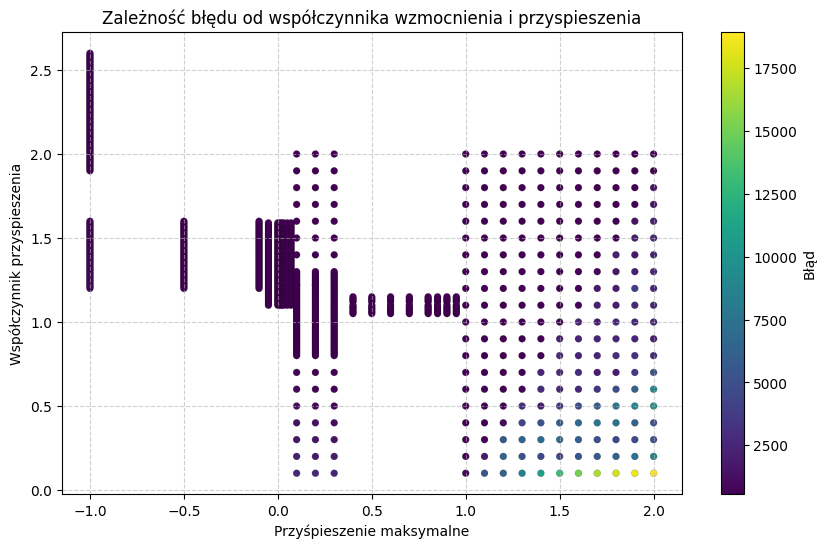

In [119]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_d2lsd['wzmocnienie'], 
                 df_d2lsd['przyspieszenie'],
                 c=df_d2lsd['blad'].astype(float), 
                 cmap='viridis', 
                 s=25,
                 edgecolor='black', 
                 linewidth=0.1)

cbar = plt.colorbar(sc)
cbar.set_label('Błąd') 

plt.ylabel("Współczynnik przyspieszenia")
plt.xlabel("Przyśpieszenie maksymalne")
plt.title("Zależność błędu od współczynnika wzmocnienia i przyspieszenia")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()